In [1]:
!pip install numpy pandas scipy scikit-learn torch matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time
import os

In [3]:
DATA_PATH = r'C:/Users/SPAC6/Desktop/python data/data/'
import os; os.makedirs(r'C:/Users/SPAC6/Desktop/python data/형민/save/CNN/', exist_ok=True)
print('DATA_PATH:', DATA_PATH)

DATA_PATH: C:/Users/SPAC6/Desktop/python data/data/


In [4]:
sensor1 = pd.read_csv(DATA_PATH + 'g1_sensor1.csv', names = ['time', 'normal', 'type1', 'type2', 'type3'])
sensor2 = pd.read_csv(DATA_PATH + 'g1_sensor2.csv', names = ['time', 'normal', 'type1', 'type2', 'type3'])
sensor3 = pd.read_csv(DATA_PATH + 'g1_sensor3.csv', names = ['time', 'normal', 'type1', 'type2', 'type3'])
sensor4 = pd.read_csv(DATA_PATH + 'g1_sensor4.csv', names = ['time', 'normal', 'type1', 'type2', 'type3'])

In [5]:
sensor1

,time,normal,type1,type2,type3
0,0.000000,-0.853307,-3.464579,0.555219,3.919664
1,0.000736,-0.740463,-2.448986,-0.234687,4.145351
2,0.001472,-0.138630,-1.922383,-0.009000,2.941685
3,0.002208,0.049443,-0.906790,-0.272301,2.603155
4,0.002944,-0.289088,-0.568259,-0.986978,1.361874
...,...,...,...,...,...
190213,139.996768,-1.156354,-2.696750,0.844491,-2.109427
190214,139.997504,-0.930666,-1.380241,0.919720,-2.222270
190215,139.998240,-0.554521,-2.132532,0.731647,-2.109427
190216,139.998976,-1.419655,-2.433448,1.183022,-3.087405


In [6]:
print('sensor 1의 데이터 크기', sensor1.shape)
print('sensor 2의 데이터 크기', sensor2.shape)
print('sensor 3의 데이터 크기', sensor3.shape)
print('sensor 4의 데이터 크기', sensor4.shape)

sensor 1의 데이터 크기 (190218, 5)
sensor 2의 데이터 크기 (184211, 5)
sensor 3의 데이터 크기 (196079, 5)
sensor 4의 데이터 크기 (183969, 5)


In [7]:
from scipy import interpolate
x_new = np.arange(0, 140, 0.001)
y_new1 = []; y_new2 = []; y_new3 = []; y_new4 = []
for item in ['normal', 'type1', 'type2', 'type3']:
    f_linear1 = interpolate.interp1d(sensor1['time'], sensor1[item], kind='linear');
    y_new1.append(f_linear1(x_new))
    f_linear2 = interpolate.interp1d(sensor2['time'], sensor2[item], kind='linear');
    y_new2.append(f_linear2(x_new))
    f_linear3 = interpolate.interp1d(sensor3['time'], sensor3[item], kind='linear');
    y_new3.append(f_linear3(x_new))
    f_linear4 = interpolate.interp1d(sensor4['time'], sensor4[item], kind='linear');
    y_new4.append(f_linear4(x_new))

sensor1 = pd.DataFrame(np.array(y_new1).T, columns = ['normal', 'type1', 'type2', 'type3'])
sensor2 = pd.DataFrame(np.array(y_new2).T, columns = ['normal', 'type1', 'type2', 'type3'])
sensor3 = pd.DataFrame(np.array(y_new3).T, columns = ['normal', 'type1', 'type2', 'type3'])
sensor4 = pd.DataFrame(np.array(y_new4).T, columns = ['normal', 'type1', 'type2', 'type3'])

In [8]:
sensor1

,normal,type1,type2,type3
0,-0.853307,-3.464579,0.555219,3.919664
1,-0.524588,-2.260096,-0.153734,3.713601
2,-0.003708,-1.193805,-0.197890,2.698827
3,-0.297674,-0.490986,-0.972668,1.338978
4,-0.091203,0.790771,-0.913384,0.701167
...,...,...,...,...
139995,-1.057411,-1.389236,0.664186,-1.498190
139996,-0.513635,-1.368793,1.050553,-0.982626
139997,-1.085213,-2.281763,0.868204,-2.144997
139998,-0.677177,-1.887220,0.792975,-2.146224


In [9]:
normal_ = pd.concat([sensor1['normal'], sensor2['normal'], sensor3['normal'],
sensor4['normal']], axis=1)
type1_ = pd.concat([sensor1['type1'], sensor2['type1'], sensor3['type1'],
sensor4['type1']], axis=1)
type2_ = pd.concat([sensor1['type2'], sensor2['type2'], sensor3['type2'],
sensor4['type2']], axis=1)
type3_ = pd.concat([sensor1['type3'], sensor2['type3'], sensor3['type3'],
sensor4['type3']], axis=1)
normal_.columns = ['s1', 's2', 's3', 's4']; type1_.columns = ['s1', 's2', 's3', 's4']
type2_.columns = ['s1', 's2', 's3', 's4']; type3_.columns = ['s1', 's2', 's3', 's4']

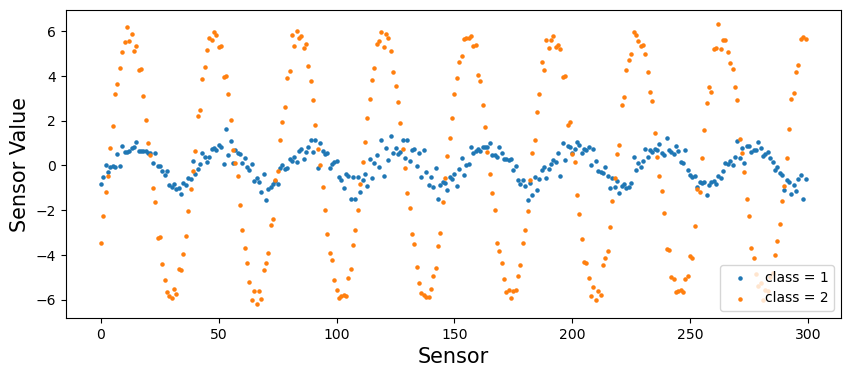

In [10]:
plt.figure(figsize = (10, 4))
plt.scatter(range(0,300), normal_['s1'][:300], label="class = "+str(1), marker='o', s=5)
plt.scatter(range(0,300), type1_['s1'][:300], label="class = "+str(2), marker='o', s=5)
plt.legend(loc="lower right")
plt.xlabel("Sensor", fontsize=15)
plt.ylabel("Sensor Value", fontsize=15)
plt.show()
plt.close()

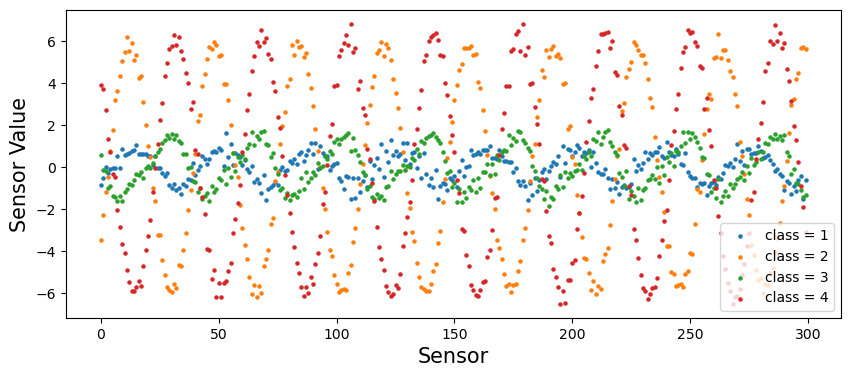

In [11]:
plt.figure(figsize = (10, 4))
plt.scatter(range(0,300), normal_['s1'][:300], label="class = "+str(1), marker='o', s=5)
plt.scatter(range(0,300), type1_['s1'][:300], label="class = "+str(2), marker='o', s=5)
plt.scatter(range(0,300), type2_['s1'][:300], label="class = "+str(3), marker='o', s=5)
plt.scatter(range(0,300), type3_['s1'][:300], label="class = "+str(4), marker='o', s=5)
plt.legend(loc="lower right")
plt.xlabel("Sensor", fontsize=15)
plt.ylabel("Sensor Value", fontsize=15)
plt.show()
plt.close()

In [12]:
print('sensor 1의 데이터 크기', sensor1.shape)
print('sensor 2의 데이터 크기', sensor2.shape)
print('sensor 3의 데이터 크기', sensor3.shape)
print('sensor 4의 데이터 크기', sensor4.shape)

sensor 1의 데이터 크기 (140000, 4)
sensor 2의 데이터 크기 (140000, 4)
sensor 3의 데이터 크기 (140000, 4)
sensor 4의 데이터 크기 (140000, 4)


In [13]:
normal_.corr()

,s1,s2,s3,s4
s1,1.000000,-0.007093,0.004297,-0.003377
s2,-0.007093,1.000000,-0.002992,0.111121
s3,0.004297,-0.002992,1.000000,-0.006434
s4,-0.003377,0.111121,-0.006434,1.000000


<Axes: >

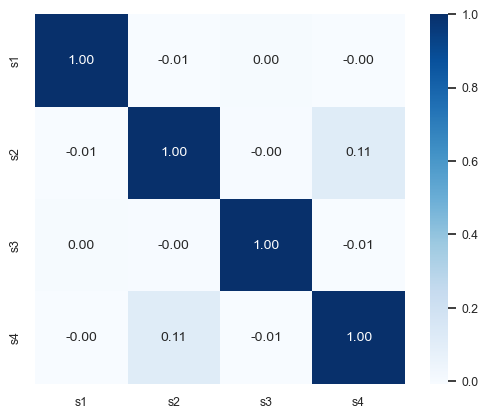

In [14]:
names = ['s1','s2','s3','s4']
cm = np.corrcoef(normal_[names].values.T)
sns.set(font_scale=0.8)
sns.heatmap(cm, annot=True, square=True, fmt='.2f', annot_kws={'size': 10},
yticklabels=names, xticklabels=names, cmap=plt.cm.Blues)

In [15]:
M = 15

# 1. Normal 데이터 필터링 및 형태 변환
normal_s1 = np.convolve(normal_['s1'], np.ones(M), 'valid') / M
normal_s1 = normal_s1.reshape(len(normal_s1), 1)
normal_s2 = np.convolve(normal_['s2'], np.ones(M), 'valid') / M
normal_s2 = normal_s2.reshape(len(normal_s2), 1)
normal_s3 = np.convolve(normal_['s3'], np.ones(M), 'valid') / M
normal_s3 = normal_s3.reshape(len(normal_s3), 1)
normal_s4 = np.convolve(normal_['s4'], np.ones(M), 'valid') / M
normal_s4 = normal_s4.reshape(len(normal_s4), 1)

# 2. Type1 데이터 필터링 및 형태 변환
type1_s1 = np.convolve(type1_['s1'], np.ones(M), 'valid') / M
type1_s1 = type1_s1.reshape(len(type1_s1), 1)
type1_s2 = np.convolve(type1_['s2'], np.ones(M), 'valid') / M
type1_s2 = type1_s2.reshape(len(type1_s2), 1)
type1_s3 = np.convolve(type1_['s3'], np.ones(M), 'valid') / M
type1_s3 = type1_s3.reshape(len(type1_s3), 1)
type1_s4 = np.convolve(type1_['s4'], np.ones(M), 'valid') / M
type1_s4 = type1_s4.reshape(len(type1_s4), 1)

# 3. Type2 데이터 필터링 및 형태 변환
type2_s1 = np.convolve(type2_['s1'], np.ones(M), 'valid') / M
type2_s1 = type2_s1.reshape(len(type2_s1), 1)
type2_s2 = np.convolve(type2_['s2'], np.ones(M), 'valid') / M
type2_s2 = type2_s2.reshape(len(type2_s2), 1)
type2_s3 = np.convolve(type2_['s3'], np.ones(M), 'valid') / M
type2_s3 = type2_s3.reshape(len(type2_s3), 1)
type2_s4 = np.convolve(type2_['s4'], np.ones(M), 'valid') / M
type2_s4 = type2_s4.reshape(len(type2_s4), 1)

# 4. Type3 데이터 필터링 및 형태 변환
type3_s1 = np.convolve(type3_['s1'], np.ones(M), 'valid') / M
type3_s1 = type3_s1.reshape(len(type3_s1), 1)
type3_s2 = np.convolve(type3_['s2'], np.ones(M), 'valid') / M
type3_s2 = type3_s2.reshape(len(type3_s2), 1)
type3_s3 = np.convolve(type3_['s3'], np.ones(M), 'valid') / M
type3_s3 = type3_s3.reshape(len(type3_s3), 1)
type3_s4 = np.convolve(type3_['s4'], np.ones(M), 'valid') / M
type3_s4 = type3_s4.reshape(len(type3_s4), 1)

# 5. 데이터 합치기 (Concatenate)
normal_temp = np.concatenate((normal_s1, normal_s2, normal_s3, normal_s4), axis=1)
type1_temp  = np.concatenate((type1_s1,  type1_s2,  type1_s3,  type1_s4),  axis=1)
type2_temp  = np.concatenate((type2_s1,  type2_s2,  type2_s3,  type2_s4),  axis=1)
type3_temp  = np.concatenate((type3_s1,  type3_s2,  type3_s3,  type3_s4),  axis=1)

print("데이터 전처리가 완료되었습니다.")
print("normal_temp shape:", normal_temp.shape)

데이터 전처리가 완료되었습니다.
normal_temp shape: (139986, 4)


In [16]:
normal_

,s1,s2,s3,s4
0,-0.853307,0.048823,-0.437626,-1.116226
1,-0.524588,-0.029477,-0.149817,-0.659694
2,-0.003708,-0.004751,0.280889,-0.857345
3,-0.297674,0.009673,-0.303281,-0.685318
4,-0.091203,0.096215,-0.320263,-0.303108
...,...,...,...,...
139995,-1.057411,0.587429,0.275044,0.289837
139996,-0.513635,-0.137874,-0.045973,0.131462
139997,-1.085213,0.002242,-0.164593,-0.087380
139998,-0.677177,-0.308897,0.288252,1.319862


In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(normal_)
normal = scaler.transform(normal_temp)
type1  = scaler.transform(type1_temp)
type2  = scaler.transform(type2_temp)
type3  = scaler.transform(type3_temp)
print("데이터 정규화가 완료되었습니다.")

데이터 정규화가 완료되었습니다.


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [18]:
print(normal)
print('------------------------------------------------')
print('normal data size = ', normal.shape)

[[0.57598822 0.50553898 0.56439491 0.44551164]
 [0.60960317 0.50513674 0.58169332 0.44848001]
 [0.62990663 0.5047345  0.59547186 0.46260474]
 ...
 [0.51874981 0.50106998 0.60999194 0.50715712]
 [0.49713039 0.51588928 0.6074125  0.53093987]
 [0.45708747 0.52025039 0.60349765 0.53976513]]
------------------------------------------------
normal data size =  (139986, 4)


In [19]:
normal

array([[0.57598822, 0.50553898, 0.56439491, 0.44551164],
       [0.60960317, 0.50513674, 0.58169332, 0.44848001],
       [0.62990663, 0.5047345 , 0.59547186, 0.46260474],
       ...,
       [0.51874981, 0.50106998, 0.60999194, 0.50715712],
       [0.49713039, 0.51588928, 0.6074125 , 0.53093987],
       [0.45708747, 0.52025039, 0.60349765, 0.53976513]],
      shape=(139986, 4))

In [20]:
normal = normal[30000:130000][:]
type1  = type1 [30000:130000][:]
type2  = type2 [30000:130000][:]
type3  = type3 [30000:130000][:]
print(normal)
print('------------------------------------------------')
print('normal data size = ', normal.shape)

[[0.42588581 0.56360116 0.59076635 0.45259554]
 [0.39980512 0.54859132 0.57699856 0.4486034 ]
 [0.38031149 0.54190146 0.57998374 0.44726771]
 ...
 [0.48028648 0.53048363 0.62114742 0.51024851]
 [0.44818273 0.53444251 0.62103995 0.49126006]
 [0.42832757 0.5501298  0.60917718 0.47827626]]
------------------------------------------------
normal data size =  (100000, 4)


In [21]:
# ─────────────────────────────────────────────────────────────────
# [STFT+2D-CNN 추가] 슬라이딩 윈도우 파라미터 설정
#   WINDOW_SIZE : 256 포인트 = 256 ms @ 1 kHz 샘플링
#   STRIDE      : 32  포인트 = 32  ms (87.5% 오버랩)
#   N_FFT       : 64  → 주파수 빈 = 64//2+1 = 33
#   HOP_LENGTH  : 16  → 시간 프레임 = (256-64)//16+1 = 13
# ─────────────────────────────────────────────────────────────────
WINDOW_SIZE = 256
STRIDE      = 32
N_FFT       = 64
HOP_LENGTH  = 16

def make_windows(data, window_size=WINDOW_SIZE, stride=STRIDE):
    """
    시계열 데이터 → 슬라이딩 윈도우 배열
    data    : (N, 4) 형태  (4-센서 시계열)
    Returns : (num_windows, 4, window_size) 형태
    """
    windows = []
    for start in range(0, data.shape[0] - window_size + 1, stride):
        w = data[start : start + window_size].T   # (4, window_size)
        windows.append(w)
    return np.array(windows, dtype=np.float32)

# 각 클래스에 윈도우 적용
normal_win = make_windows(normal)
type1_win  = make_windows(type1)
type2_win  = make_windows(type2)
type3_win  = make_windows(type3)

print(f'윈도우 생성 완료!')
print(f'클래스당 윈도우 수 : {normal_win.shape[0]}')
print(f'윈도우 형태        : {normal_win.shape}   (클래스 수, 채널 수, 윈도우 크기)')

윈도우 생성 완료!
클래스당 윈도우 수 : 3118
윈도우 형태        : (3118, 4, 256)   (클래스 수, 채널 수, 윈도우 크기)


In [22]:
# ─────────────────────────────────────────────────────────────────
# [STFT+2D-CNN 추가] 슬라이딩 윈도우 → STFT 스펙트로그램 변환
#
#  각 윈도우(256 포인트) × 각 센서(4채널)에 대해 STFT 적용
#  → 로그-진폭 스펙트로그램 : (N_windows, 4채널, 33 freq, 13 time)
# ─────────────────────────────────────────────────────────────────

def windows_to_stft(windows, n_fft=N_FFT, hop=HOP_LENGTH):
    """
    windows : (N, 4, W) numpy 배열
    Returns : (N, 4, freq_bins, time_frames) 로그-스펙트로그램
    """
    N, C, W = windows.shape
    freq_bins   = n_fft // 2 + 1          # 33
    time_frames = (W - n_fft) // hop + 1  # 13

    # torch.stft 를 이용한 빠른 배치 처리
    t    = torch.from_numpy(windows.reshape(N * C, W))  # (N*C, W)
    win_fn = torch.hann_window(n_fft)
    S    = torch.stft(t, n_fft=n_fft, hop_length=hop, win_length=n_fft,
                      window=win_fn, center=False, return_complex=True)
    S_log = torch.log1p(S.abs())           # 로그 스케일 크기
    return S_log.reshape(N, C, freq_bins, time_frames).numpy()

t_stft_total_start = time.time()

print('STFT 변환 중... (Normal)', end=' ')
t0 = time.time(); normal_spec = windows_to_stft(normal_win); print(f'완료  ({time.time()-t0:.3f}s)')
print('STFT 변환 중... (Type1) ', end=' ')
t0 = time.time(); type1_spec  = windows_to_stft(type1_win);  print(f'완료  ({time.time()-t0:.3f}s)')
print('STFT 변환 중... (Type2) ', end=' ')
t0 = time.time(); type2_spec  = windows_to_stft(type2_win);  print(f'완료  ({time.time()-t0:.3f}s)')
print('STFT 변환 중... (Type3) ', end=' ')
t0 = time.time(); type3_spec  = windows_to_stft(type3_win);  print(f'완료  ({time.time()-t0:.3f}s)')

t_stft_total = time.time() - t_stft_total_start
print(f'\n[STFT 전체 변환 시간] {t_stft_total:.3f}s ({t_stft_total/60:.2f}min)')

FREQ_BINS   = normal_spec.shape[2]   # 33
TIME_FRAMES = normal_spec.shape[3]   # 13
print(f'\n스펙트로그램 형태 : {normal_spec.shape}')
print(f'  채널 수    : 4  (센서 4개)')
print(f'  주파수 빈  : {FREQ_BINS}  (0 ~ 500 Hz)')
print(f'  시간 프레임: {TIME_FRAMES}')

STFT 변환 중... (Normal) 완료  (0.140s)
STFT 변환 중... (Type1)  완료  (0.020s)
STFT 변환 중... (Type2)  완료  (0.026s)
STFT 변환 중... (Type3)  완료  (0.024s)

[STFT 전체 변환 시간] 0.211s (0.00min)

스펙트로그램 형태 : (3118, 4, 33, 13)
  채널 수    : 4  (센서 4개)
  주파수 빈  : 33  (0 ~ 500 Hz)
  시간 프레임: 13


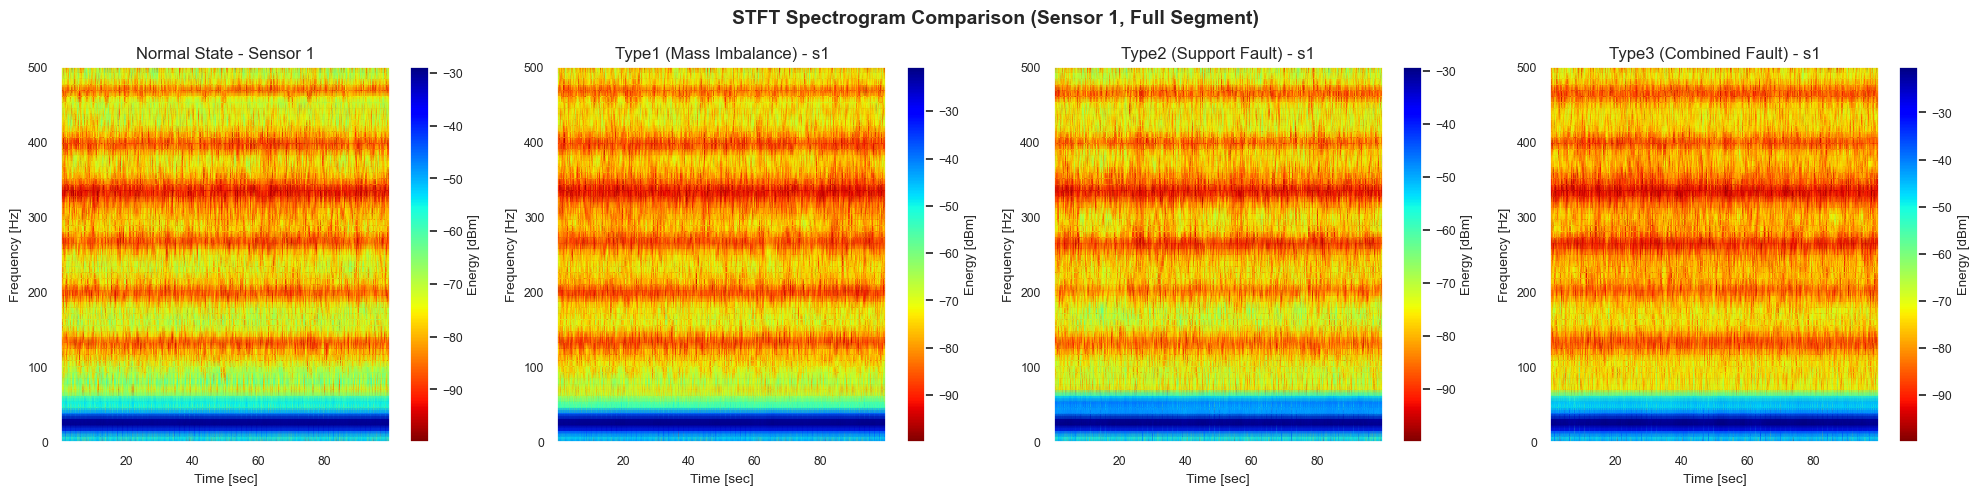

In [23]:
# ─────────────────────────────────────────────
# Spectrogram Visualization  (scipy, dB scale)
# ─────────────────────────────────────────────
import scipy.signal as signal_

Fs         = 1000
N_FFT_VIZ  = 128
HOP_VIZ    = 32

def plot_spectrogram(raw_signal_1d, title, ax, fs=Fs, n_fft=N_FFT_VIZ, hop=HOP_VIZ):
    f, t, Sxx = signal_.spectrogram(
        raw_signal_1d,
        fs       = fs,
        window   = signal_.get_window('hann', n_fft),
        nperseg  = n_fft,
        noverlap = n_fft - hop,
        scaling  = 'density'
    )
    Sxx_dB = 10 * np.log10(Sxx + 1e-10)
    im = ax.pcolormesh(t, f, Sxx_dB, shading='gouraud', cmap='jet_r')  # jet_r = color reversed
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Time [sec]', fontsize=10)
    ax.set_ylabel('Frequency [Hz]', fontsize=10)
    plt.colorbar(im, ax=ax, label='Energy [dBm]')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
plot_spectrogram(normal[:, 0], 'Normal State - Sensor 1',       axes[0])
plot_spectrogram(type1[:,  0], 'Type1 (Mass Imbalance) - s1',   axes[1])
plot_spectrogram(type2[:,  0], 'Type2 (Support Fault) - s1',    axes[2])
plot_spectrogram(type3[:,  0], 'Type3 (Combined Fault) - s1',   axes[3])

plt.suptitle('STFT Spectrogram Comparison (Sensor 1, Full Segment)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

In [24]:
# 데이터 분배 (슬라이싱) - 스펙트로그램 기준
# 원본과 동일한 비율: 60% 학습 / 20% 검증 / 20% 시험
n_total = normal_spec.shape[0]           # 클래스당 윈도우 수
t1      = int(n_total * 0.6)             # 60% 학습
t2      = int(n_total * 0.8)             # 80% 지점 (검증 끝)

normal_train = normal_spec[:t1];  normal_valid = normal_spec[t1:t2]; normal_test = normal_spec[t2:]
type1_train  = type1_spec [:t1];  type1_valid  = type1_spec [t1:t2]; type1_test  = type1_spec [t2:]
type2_train  = type2_spec [:t1];  type2_valid  = type2_spec [t1:t2]; type2_test  = type2_spec [t2:]
type3_train  = type3_spec [:t1];  type3_valid  = type3_spec [t1:t2]; type3_test  = type3_spec [t2:]

# 합치기
train = np.concatenate((normal_train, type1_train, type2_train, type3_train))
valid = np.concatenate((normal_valid, type1_valid, type2_valid, type3_valid))
test  = np.concatenate((normal_test,  type1_test,  type2_test,  type3_test))

print("train 스펙트로그램 형태:", train.shape)
print("valid 스펙트로그램 형태:", valid.shape)
print(" test 스펙트로그램 형태:", test.shape)

train 스펙트로그램 형태: (7480, 4, 33, 13)
valid 스펙트로그램 형태: (2496, 4, 33, 13)
 test 스펙트로그램 형태: (2496, 4, 33, 13)


In [25]:
n_tr = t1
n_va = t2 - t1
n_te = n_total - t2

train_label = np.concatenate((np.full((n_tr,1),0), np.full((n_tr,1),1),
                               np.full((n_tr,1),2), np.full((n_tr,1),3)))
valid_label = np.concatenate((np.full((n_va,1),0), np.full((n_va,1),1),
                               np.full((n_va,1),2), np.full((n_va,1),3)))
test_label  = np.concatenate((np.full((n_te,1),0), np.full((n_te,1),1),
                               np.full((n_te,1),2), np.full((n_te,1),3)))
print('데이터 라벨링 완료')

데이터 라벨링 완료


In [26]:
idx = np.arange(train.shape[0]); np.random.shuffle(idx);
train = train[:][idx]; train_label = train_label[:][idx]
idx_v = np.arange(valid.shape[0]); np.random.shuffle(idx_v);
valid = valid[:][idx_v]; valid_label = valid_label[:][idx_v]
idx_t = np.arange(test.shape[0]); np.random.shuffle(idx_t);
test  = test[:][idx_t]; test_label  = test_label[:][idx_t]
print('데이터 뒤섞기 완료')

데이터 뒤섞기 완료


In [27]:
# 변경 전
x_train = torch.from_numpy(train).float()           # (N, 4, 33, 13) 스펙트로그램
y_train = torch.from_numpy(train_label).float().T[0]
x_valid = torch.from_numpy(valid).float()
y_valid = torch.from_numpy(valid_label).float().T[0]
x_test  = torch.from_numpy(test).float()
y_test  = torch.from_numpy(test_label).float().T[0]
print('변경 후')
x_train

변경 후


tensor([[[[2.8222e+00, 2.9422e+00, 2.8327e+00,  ..., 2.9047e+00,
           2.8913e+00, 2.8492e+00],
          [1.5556e+00, 2.6695e+00, 1.8772e+00,  ..., 2.5070e+00,
           2.4395e+00, 2.1022e+00],
          [2.0640e+00, 2.0648e+00, 2.0643e+00,  ..., 2.0614e+00,
           2.0524e+00, 2.0573e+00],
          ...,
          [1.4758e-02, 4.3677e-03, 4.4936e-03,  ..., 2.4182e-02,
           7.6455e-03, 3.0342e-02],
          [3.4768e-02, 1.6802e-02, 1.7326e-02,  ..., 4.1823e-03,
           2.4049e-02, 3.7992e-02],
          [5.8722e-02, 3.2001e-02, 6.5678e-03,  ..., 1.6415e-02,
           3.4824e-02, 4.6363e-02]],

         [[2.8671e+00, 2.8037e+00, 2.8548e+00,  ..., 2.8311e+00,
           2.8234e+00, 2.8554e+00],
          [2.4437e+00, 1.9180e+00, 2.3813e+00,  ..., 2.2133e+00,
           2.1511e+00, 2.3934e+00],
          [1.4920e+00, 1.4674e+00, 1.4942e+00,  ..., 1.4642e+00,
           1.4656e+00, 1.4891e+00],
          ...,
          [9.6837e-03, 9.7491e-03, 1.9895e-02,  ..., 3.8599

In [28]:
print('변경 후')
x_train

변경 후


tensor([[[[2.8222e+00, 2.9422e+00, 2.8327e+00,  ..., 2.9047e+00,
           2.8913e+00, 2.8492e+00],
          [1.5556e+00, 2.6695e+00, 1.8772e+00,  ..., 2.5070e+00,
           2.4395e+00, 2.1022e+00],
          [2.0640e+00, 2.0648e+00, 2.0643e+00,  ..., 2.0614e+00,
           2.0524e+00, 2.0573e+00],
          ...,
          [1.4758e-02, 4.3677e-03, 4.4936e-03,  ..., 2.4182e-02,
           7.6455e-03, 3.0342e-02],
          [3.4768e-02, 1.6802e-02, 1.7326e-02,  ..., 4.1823e-03,
           2.4049e-02, 3.7992e-02],
          [5.8722e-02, 3.2001e-02, 6.5678e-03,  ..., 1.6415e-02,
           3.4824e-02, 4.6363e-02]],

         [[2.8671e+00, 2.8037e+00, 2.8548e+00,  ..., 2.8311e+00,
           2.8234e+00, 2.8554e+00],
          [2.4437e+00, 1.9180e+00, 2.3813e+00,  ..., 2.2133e+00,
           2.1511e+00, 2.3934e+00],
          [1.4920e+00, 1.4674e+00, 1.4942e+00,  ..., 1.4642e+00,
           1.4656e+00, 1.4891e+00],
          ...,
          [9.6837e-03, 9.7491e-03, 1.9895e-02,  ..., 3.8599

In [29]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

BATCH_SIZE = 128

train_ds = TensorDataset(x_train, y_train)
train_dataloader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

valid_ds = TensorDataset(x_valid, y_valid)
valid_dataloader = DataLoader(valid_ds, batch_size=len(x_valid), shuffle=False)

test_ds  = TensorDataset(x_test, y_test)
test_dataloader  = DataLoader(test_ds,  batch_size=len(x_test),  shuffle=False)

In [30]:
# ─────────────────────────────────────────────────────────────────
# KAMP_STFT_CNN2D  모델 정의
#
#  [원본 KAMP_CNN 대응 관계]
#  KAMP_CNN (1D)              KAMP_STFT_CNN2D (2D)
#  Conv1d(1→100, k=2)  ←→   Conv2d(4→64,  k=3)   입력 채널: 센서 4개
#  Conv1d(100→100,k=2) ←→   Conv2d(64→64, k=3)
#  Conv1d(100→100,k=2) ←→   Conv2d(64→4,  k=3)
#  Conv1d(100→4,  k=2) (생략)
#  AdaptiveAvgPool1d(1)←→   AdaptiveAvgPool2d(1)  전역 평균 풀링
#  Linear(4→4)         ←→   Linear(4→4)           4-클래스 분류기
#
#  입력 : (Batch, 4채널, 33 freq, 13 time)
#  출력 : (Batch, 4)  →  Normal / Type1 / Type2 / Type3
# ─────────────────────────────────────────────────────────────────
class KAMP_STFT_CNN2D(nn.Module):
    def __init__(self):
        # 1. 클래스 초기화
        super(KAMP_STFT_CNN2D, self).__init__()

        # 2. 첫 번째 주방 세팅  (1D-CNN의 conv1 대응)
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=4, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 주파수×시간 절반
            nn.Dropout(p=0.2)
        )

        # 두 번째 주방 세팅  (1D-CNN의 conv2 대응)
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(p=0.2)
        )

        # 3. 마지막 주방 세팅  (1D-CNN의 conv4 대응)
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=1, stride=1)
        )

        # 4. 최종 결론 판사석 세팅  (1D-CNN의 AdaptiveAvgPool1d 대응)
        self.final_pool = nn.AdaptiveAvgPool2d(1)   # → (B, 4, 1, 1)
        self.linear     = nn.Linear(4, 4)

    def forward(self, input):
        # 데이터가 흘러가는 순서
        # input: (B, 4, FREQ_BINS, TIME_FRAMES)  -- 스펙트로그램 4채널
        out = self.conv1(input)
        out = self.conv2(out)
        out = self.conv3(out)
        out = self.final_pool(out)
        out = self.linear(out.view(out.size(0), -1))   # Flatten → Linear
        return out

# 모델 생성 및 확인
model_check = KAMP_STFT_CNN2D()
print(model_check)

# 더미 입력으로 동작 확인
dummy = torch.randn(1, 4, FREQ_BINS, TIME_FRAMES)
print('\n입력 형태:', dummy.shape)
out_check = model_check(dummy)
print('출력 형태:', out_check.shape, '  ← (Batch, 4클래스)')
print('=== 모델 정상 동작 확인 완료! ===')

KAMP_STFT_CNN2D(
  (conv1): Sequential(
    (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (final_pool): AdaptiveAvgPool2d(o

In [31]:
import torch  # 누락 방지

def train_model(model, criterion, optimizer, num_epochs, train_dataloader, PATH):

    loss_values   = []
    loss_values_v = []
    check         = 0
    accuracy_past = 0

    # 1. 100번(num_epochs)의 훈련 시작
    for epoch in range(1, num_epochs + 1):

        # ─────────────── 모델 학습 ────────────────────
        model.train()
        batch_number = 0
        running_loss = 0.0

        for batch_idx, samples in enumerate(train_dataloader):
            x_train, y_train = samples

            # 파이토치 학습 5단계 콤보
            optimizer.zero_grad()
            y_hat = model.forward(x_train)
            loss  = criterion(y_hat, y_train.long())
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            batch_number += 1

        loss_values.append(running_loss / batch_number)

        # ─────────────── 모델 검증 ────────────────────
        model.eval()
        accuracy = 0.0
        total    = 0.0

        for batch_idx, data in enumerate(valid_dataloader):
            x_valid, y_valid = data
            v_hat  = model.forward(x_valid)
            v_loss = criterion(v_hat, y_valid.long())

            _, predicted = torch.max(v_hat.data, 1)
            total    += y_valid.size(0)
            accuracy += (predicted == y_valid).sum().item()

        loss_values_v.append(v_loss.item())
        accuracy = (accuracy / total)

        if epoch % 1 == 0:
            print('[Epoch {}/{}] [Train_Loss: {:.6f} / Valid_Loss: {:.6f}]'.format(
                  epoch, num_epochs, loss.item(), v_loss.item()))
            print('[Epoch {}/{}] [Accuracy : {:.6f}]'.format(epoch, num_epochs, accuracy))

        # ─────────── Check for early stopping ──────────
        if accuracy_past > accuracy:
            check += 1
        else:
            check         = 0
            accuracy_past = accuracy

        # 50번 연속으로 성능이 떨어지면 강제 종료 (조기 종료)
        if check > 50:
            print('This is time to do early stopping (조기 종료 발동!)')
            torch.save(model, PATH + 'model_stft2d.pt')
            return loss_values, loss_values_v

    torch.save(model, PATH + 'model_stft2d.pt')
    return loss_values, loss_values_v

print('학습준비완료')

학습준비완료


In [32]:
import os

STFT_model = KAMP_STFT_CNN2D()
num_epochs  = 100
criterion   = nn.CrossEntropyLoss()
optimizer   = torch.optim.Adam(STFT_model.parameters())
PATH        = r'C:/Users/SPAC6/Desktop/python data/형민/save/CNN/'

os.makedirs(PATH, exist_ok=True)

# 계산 시간 측정 시작 (t_start)
start_time = time.time()

STFT_loss_values, STFT_loss_values_v =STFT_epoch_times = train_model(
    STFT_model, criterion, optimizer, num_epochs, train_dataloader, PATH
)

# 계산 시간 측정 종료 및 산출 (t_end - t_start)
end_time = time.time()
train_duration = end_time - start_time
print(f'STFT+2D-CNN Training Computation Time: {train_duration:.4f} seconds')

[Epoch 1/100] [Train_Loss: 0.887219 / Valid_Loss: 0.913030]
[Epoch 1/100] [Accuracy : 1.000000]
[Epoch 2/100] [Train_Loss: 0.760839 / Valid_Loss: 0.780821]
[Epoch 2/100] [Accuracy : 1.000000]
[Epoch 3/100] [Train_Loss: 0.658099 / Valid_Loss: 0.676659]
[Epoch 3/100] [Accuracy : 1.000000]
[Epoch 4/100] [Train_Loss: 0.579860 / Valid_Loss: 0.580365]
[Epoch 4/100] [Accuracy : 1.000000]
[Epoch 5/100] [Train_Loss: 0.515084 / Valid_Loss: 0.499970]
[Epoch 5/100] [Accuracy : 1.000000]
[Epoch 6/100] [Train_Loss: 0.403317 / Valid_Loss: 0.452720]
[Epoch 6/100] [Accuracy : 1.000000]
[Epoch 7/100] [Train_Loss: 0.404819 / Valid_Loss: 0.387659]
[Epoch 7/100] [Accuracy : 1.000000]
[Epoch 8/100] [Train_Loss: 0.311954 / Valid_Loss: 0.331057]
[Epoch 8/100] [Accuracy : 1.000000]
[Epoch 9/100] [Train_Loss: 0.317498 / Valid_Loss: 0.313156]
[Epoch 9/100] [Accuracy : 1.000000]
[Epoch 10/100] [Train_Loss: 0.236958 / Valid_Loss: 0.254781]
[Epoch 10/100] [Accuracy : 1.000000]
[Epoch 11/100] [Train_Loss: 0.245801 /

In [33]:
def test_model(model, PATH):
    model = torch.load(PATH + 'model_stft2d.pt', weights_only=False)
    # ─────────────── 모델 시험 ─────────────────────
    model.eval()
    total    = 0.0
    accuracy = 0.0

    for batch_idx, data in enumerate(test_dataloader):
        x_test, y_test = data

        t_hat = model(x_test)
        _, predicted = torch.max(t_hat.data, 1)
        total    += y_test.size(0)
        accuracy += (predicted == y_test).sum().item()
        accuracy  = (accuracy / total)

    # ────────────────────────────────────────────────
    print(accuracy)
    print('STFT+2D-CNN 모델 평가 완료')

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

def draw_confusion_matrix(model, xt, yt, PATH):
    y_pred = []; y_true = []
    model.eval()

    y_hat  = model(xt)
    output = (torch.max(torch.exp(y_hat), 1)[1]).data.cpu().numpy()
    y_pred.extend(output)

    labels = yt.data.cpu().numpy()
    y_true.extend(labels)

    # 분류 항목
    classes = ('Normal', 'Type1', 'Type2', 'Type3')

    # Confusion Matrix 생성
    plt.figure(figsize=(7, 5))
    dlen  = float(len(x_test))
    cm    = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm / dlen,
                         index   =[i for i in classes],
                         columns =[i for i in classes])

    sns.heatmap(df_cm, annot=True, cmap=plt.cm.Blues)
    plt.title('Confusion Matrix', size=24, fontweight='bold')
    plt.xlabel('Predicted Label', size=16)
    plt.ylabel('Actual Label',    size=16)

    plt.rc('xtick', labelsize=12); plt.rc('ytick', labelsize=12); plt.yticks(rotation=0)
    plt.savefig(PATH + 'cm_stft2d_output.png')

In [35]:
def plot_loss_graph(loss_values, loss_values_v):
    plt.figure()
    plt.plot(loss_values)
    plt.plot(loss_values_v)
    plt.title('Training & Validation Loss  (STFT+2D-CNN)')
    plt.ylabel('loss',  fontsize='large')
    plt.xlabel('epoch', fontsize='large')
    plt.legend(['train', 'validation'])
    plt.tight_layout()

    # 결과 저장
    plt.savefig(PATH + 'lossplot_stft2d_output.png')

In [36]:
import time

PATH = r'C:/Users/SPAC6/Desktop/python data/형민/save/CNN/'

# 계산 시간 측정 시작
start_time = time.time()
# 모델 테스트 및 평가
test_model(STFT_model, PATH)

# 계산 시간 산출
end_time = time.time()
test_duration = end_time - start_time
print(f'STFT+2D-CNN Inference Computation Time: {test_duration:.4f} seconds')

1.0
STFT+2D-CNN 모델 평가 완료
STFT+2D-CNN Inference Computation Time: 0.3385 seconds


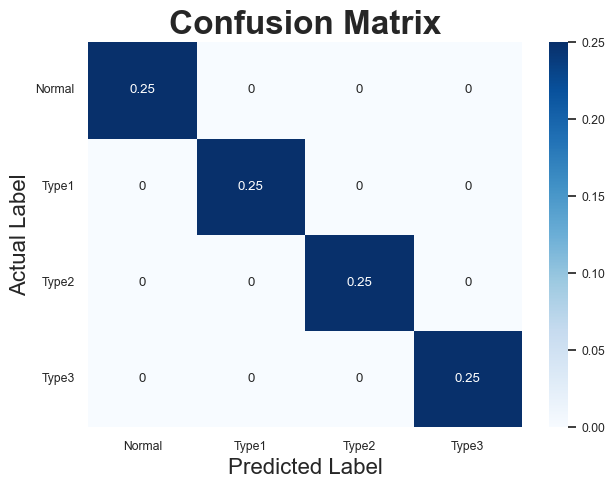

In [37]:
draw_confusion_matrix(STFT_model, x_test, y_test, PATH)

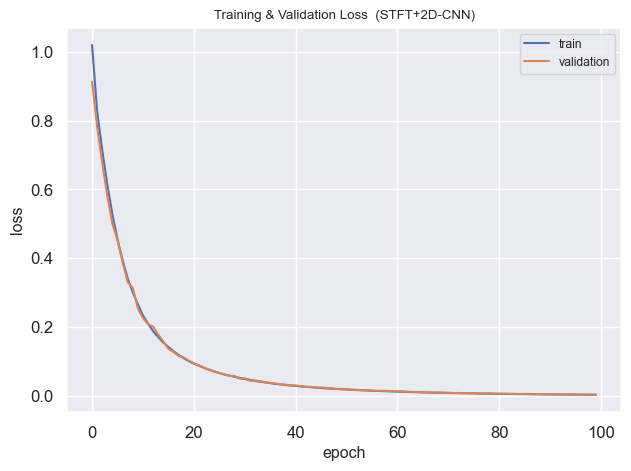

In [38]:
plot_loss_graph(STFT_loss_values, STFT_loss_values_v)